In [1]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

DATA_PATH = Path("data/council.txt")

text = DATA_PATH.read_text(encoding="utf-8")


/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
print(text)

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

In [3]:
# RAG : text -> chunking -> embedding -> vs -> query -> top-k -> context, query -> llm -> answer (Naive RAG)

# Advanced RAG
# BM25 hybrid search
# reranking
# 쿼리 rewriting,
# ..

In [4]:
# Graph : entity, relation

In [5]:
# 파리타 대학교는 눌마리 동부 해안에 위치한 종합 연구 대학교로, 현재 레하즈 콜노 학장이 이끈다.
# 레하즈 콜노 학장 ----- lead ----> 파리타 대학교

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50, separators= ['\n\n', '\n', '. ', ' ', ''])

In [7]:
demo = splitter.split_text(text)
chunks = splitter.split_text(text)

In [8]:
for de in demo:
    print(de)
    print()

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

In [9]:
v1 = embeddings.embed_query('노라셋의 공명 하드웨어')
v2 = embeddings.embed_query('노라셋 엔지니어링 그룹이 설계하고 제작하는 주력 제품은 공명 기반의 연산 하드웨어이다. 이 하드웨어는 벨트란 사고 엔진과 눌마리 전역의 여러 기호 추론 시스템에 전력을 공급하는 핵심 부품으로 사용된다. 노라셋의 공명 하드웨어는 눌마리 밖으로는 거의 수출되지 않는다.')

In [10]:
len(v1)

1536

In [11]:
import numpy as np

In [12]:
def cos(x, y):
    return float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))

In [13]:
cos(np.array(v1), np.array(v2))

0.6223177941502015

In [14]:
mini_vs = FAISS.from_texts(['오브루리 축제는 매년 늦가을에 눌마리 섬에서 사흘 동안 열리는 문화 축제이다.', 
                           '노라셋 엔지니어링 그룹이 설계하고 제작하는 주력 제품은 공명 기반의 연산 하드웨어이다.'], embeddings)

In [15]:
mini_vs.similarity_search('오브루리 축제', k=1)

[Document(id='525582fe-b9f4-4012-9c8d-5ea116de8fd4', metadata={}, page_content='오브루리 축제는 매년 늦가을에 눌마리 섬에서 사흘 동안 열리는 문화 축제이다.')]

In [16]:
def build_vector_store(chunks : list[str]) -> FAISS:
    return FAISS.from_texts(chunks, embeddings)

In [17]:
vs = build_vector_store(chunks)

In [18]:
test = vs.similarity_search('콰빅스', k=1)

In [19]:
test

[Document(id='73b6a73b-45ea-4364-b060-27599ca7f6a6', metadata={}, page_content='제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.')]

In [20]:
hits = vs.similarity_search_with_score('콰빅스 연구소 설립자', k=3)

In [21]:
for doc, dist in hits:
    print(f"{dist} : {doc.page_content}")

0.687883734703064 : 제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.
1.1696476936340332 : 제목: 코바쉬 연구소
코바쉬 연구소는 북부 눌마리의 사설 AI 연구소로, 2001 년에 설립되었고 현재는 옌라 톨름이 소장을 맡고 있다. 코바쉬의 대표 아키텍처인 발레미르 엔진은 상업 배포 시장에서 타즈렌의 드리파와 직접 경쟁하는 위치에 있다. 톨름은 파리타 대학교에서 박사 과정을 마쳤으며, 그 시기의 지도 교수는 당시 파리타의 학장이기도 했던 레하즈 콜노였다.
1.2559103965759277 : 제목: 눌마리 연구 위원회
눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.


In [22]:
def retrieve(query, vs, k):
    return [d.page_content  for d in vs.similarity_search(query, k=k)]

In [23]:
sample = retrieve('콰빅스 연구소 설립자', vs, k=3)
for i, c in enumerate(sample):
    print(f"\n[{i}] {c[:100]}")


[0] 제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으

[1] 제목: 코바쉬 연구소
코바쉬 연구소는 북부 눌마리의 사설 AI 연구소로, 2001 년에 설립되었고 현재는 옌라 톨름이 소장을 맡고 있다. 코바쉬의 대표 아키텍처인 발레미르 엔진은 

[2] 제목: 눌마리 연구 위원회
눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모


In [24]:
def naive_rag(question, vs, k=3):
    chunks = retrieve(question, vs, k=k)
    ctx = '\n\n'.join(f"[{i+1}] {c}" for i, c in enumerate(chunks))
    sys = SystemMessage(content = "주어진 컨텍스트만으로 한국어로 답하세요, 컨텍스트에 답이 없으면 문서에서 찾을수 없다고 답하세요")
    user = HumanMessage(content = f"컨텍스트:\n{ctx}\n\n질문 : {question}")
    
    return llm.invoke([sys, user]).content

In [25]:
naive_rag('콰빅스 연구소는 언제 설립됐나요?', vs, 3)

'콰빅스 연구소는 1987 년 초여름에 설립되었습니다.'

In [26]:
naive_rag('콰빅스 연구소를 지은 사람은 누구인가요?', vs, 3)

'콰빅스 연구소를 지은 사람은 모리카이 센입니다.'

In [27]:
chunk_list = retrieve('콰빅스 연구소를 지은 사람은 누구인가요?',vs, k=3)

In [28]:
chunk_list

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 눌마리 연구 위원회\n눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.',
 '제목: 코바쉬 연구소\n코바쉬 연구소는 북부 눌마리의 사설 AI 연구소로, 2001 년에 설립되었고 현재는 옌라 톨름이 소장을 맡고 있다. 코바쉬의 대표 아키텍처인 발레미르 엔진은 상업 배포 시장에서 타즈렌의 드리파와 직접 경쟁하는 위치에 있다. 톨름은 파리타 대학교에서 박사 과정을 마쳤으며, 그 시기의 지도 교수는 당시 파리타의 학장이기도 했던 레하즈 콜노였다.']

In [29]:
def question_contains_answer(chunks, key):
    return any(key in c for c in chunks)

In [30]:
question_contains_answer(chunk_list, "모리카이")

True

In [31]:
for de in chunks:
    print(de)
    print()

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

In [32]:
# Multi-hop question
# 모리카이 센의 멘토가 쓴 논문은 무엇인가요?
# 모리카이센의 멘토 -> 탈라미르 헤쉬
# 탈라미르 헤쉬 -> ㅇㅇㅇ 

In [33]:
naive_rag('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, 3)

'문서에서 찾을 수 없습니다.'

In [34]:
retrieve('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, 3)

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.',
 '제목: 눌마리 연구 위원회\n눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.']

In [35]:
def multihop_diagnosis(question, vs, key, k=5):
    chunks = retrieve(question, vs, k=k)
    answer = naive_rag(question, vs, k=k)
    return {
        'key_in_chunks' : any(key in c for c in chunks),
        'key_in_answers' : key in answer,
        'answer' : answer
    }

In [36]:
multihop_diagnosis('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, key='공명 프레임', k=5)

{'key_in_chunks': True,
 'key_in_answers': True,
 'answer': '모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문은 "공명 프레임에 관하여"입니다.'}

In [37]:
retrieve('모리카이 센의 멘토가 쓴 논문은 무엇인가요?', vs, k=5)

['제목: 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.',
 '제목: 할렌 프로토콜\n할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.',
 '제목: 눌마리 연구 위원회\n눌마리 연구 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 사이의 자금 조달과 인력 교류를 조정하는 공식 기구로, 자체 연구는 수행하지 않는다. 위원회는 모든 지원금 수혜 조건으로 할렌 프로토콜 사용을 요구하며, 매년 가을에 눌마리 연구 활동의 연간 리뷰를 발간하여 지난 한 해의 기관별 성과를 공개적으로 기록한다.',
 '제목: 브렌술의 학술 기여\n브렌술 아카데미는 자체 사고 엔진이나 상용 아키텍처는 출판하지 않는 것으로 오래전부터 잘 알려져 있다. 상업적 제품이 없다고 해서 영향력이 없는 것은 아니다. 브렌술에서 나온 가장 많이 인용된 논문은 탈라미르 헤쉬가 직접 집필한 "공명 프레임에 관하여" 이며, 이 논문은 원본 벨트란 설계 문서의 참고 문헌 첫 줄에 기록되어 있다. 해당 논문은 눌마리 섬 바깥의 여러 연구 기관에서도 자주 인용된다.',
 '제목: 파리타 대학교\n파리타 대학교는 눌마리 동부 해안에 

In [38]:
naive_rag('이 코퍼스의 주요 주제는 무엇인가요?', vs, k=5)

'이 코퍼스의 주요 주제는 눌마리 섬에서의 AI 연구소와 그들이 개발한 아키텍처 및 연구 활동에 관한 정보입니다. 코바쉬, 콰빅스, 타즈렌 연구소와 같은 기관들과 그들이 기여한 기술 및 연구 성과에 대한 내용이 포함되어 있습니다. 또한, 오브루리 축제와 같은 문화적 활동도 언급되며, 연구자들이 아이디어를 공유하고 논의하는 장에 대한 설명도 담겨 있습니다.'

In [39]:
# def global_diagnosis(vs, k=5):
#     institutions = ['콰빅스', '타즈렌', '브렌술' ..]
#     chunks = retrieve('이 코퍼스의 주요 주제는?', vs, k)
#     seen = []

In [40]:
for de in chunks:
    print(de)
    print()

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.

제목: 타즈렌 연구소
타즈렌 연구소는 해양 기록학자 리네아 오보스트가 1992 년에 눌마리 서쪽 해안 마을에서 문을 열었다. 오보스트는 해양학 박사 출신이지만 이후 머신러닝으로 전환한 독특한 이력을 갖고 있다. 타즈렌의 가장 유명한 기여는 드리파 아키텍처인데, 이 아키텍처는 기존의 그라디언트 흐름 대신 조류의 주기를 모사한 업데이트 방식을 쓴다. 드리파는 이후 여러 눌마리 기관에 채택되었고, 특히 해양 관측 데이터 처리에서 높은 성능을 보였다고 전해진다.

제목: 할렌 프로토콜
할렌 프로토콜은 타즈렌 연구소의 신진 연구원 에빈 브로스가 1995 년에 단독으로 작성한 데이터 큐레이션 표준이다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프가 다단계 아카이브에 걸쳐 어떻게 색인되고 재구성되는지를 세밀하게 규정하는 문서이다. 브로스는 이 문서로 눌마리 연구 위원회로부터 특별 표창을 받았고, 위원회는 이후 할렌 프로토콜을 모든 소속 기관의 기본 파이프라인으로 채택하기로 결정했다.

제목: 브렌술 아카데미
브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 북부 어촌 마을의 옛 수도원 부지에서 설립되었다. 브렌술의 현재 학장은 탈라미르 헤쉬로, 1978 년부터 이 기관에 몸담아 왔다. 헤쉬 체제의 브렌술은 매년 소수의 박사후 연구원을 받아 10 년 단위의 장기 프로젝트에 투입하는 전통을 유지하고 있으며, 이 전통이 헤쉬의 학술적 명성을 유지하는 바탕이 되

In [41]:
!pip install -q networkx


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [42]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 (시스템에 따라 다름)
for f in ["NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic"]:
    if any(f in fn.name for fn in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams["axes.unicode_minus"] = False

In [43]:
print(chunks[0])

제목: 콰빅스 연구소
모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.


In [44]:
# node
# edge
G_demo = nx.DiGraph()
G_demo.add_node('모리카이 센', type='Person')
G_demo.add_node('콰빅스 연구소', type='Organization')
G_demo.add_edge('모리카이 센', '콰빅스 연구소', relation='founded')

In [45]:
G_demo.nodes(data=True)

NodeDataView({'모리카이 센': {'type': 'Person'}, '콰빅스 연구소': {'type': 'Organization'}})

In [46]:
G_demo.edges(data=True)

OutEdgeDataView([('모리카이 센', '콰빅스 연구소', {'relation': 'founded'})])

In [47]:
# 브렌술 아카데미
# 탈라미르 헤쉬
# 벨트란 사고 엔진

In [48]:
G_demo = nx.DiGraph()
G_demo.add_node('모리카이 센', type='Person')
G_demo.add_node('콰빅스 연구소', type='Organization')
G_demo.add_node('브렌술 아카데미', type='Organization')
G_demo.add_node('탈라미르 헤쉬', type='Person')
G_demo.add_node('벨트란 사고 엔진', type='Product')

G_demo.add_edge('모리카이 센', '콰빅스 연구소', relation='founded', year=1987)
G_demo.add_edge('모리카이 센', '브렌술 아카데미', relation='postdoc_at')
G_demo.add_edge('탈라미르 헤쉬', '모리카이 센', relation='mentor_of')

# G_demo.add_edge('모리카이 센', '탈라미르 헤쉬', relation='mentored_by')
# G_demo.add_edge('벨트란 사고 엔진', '콰빅스 연구소', relation='developed_by')

G_demo.add_edge('콰빅스 연구소', '벨트란 사고 엔진', relation='develops')

In [49]:
G_demo.number_of_nodes(), G_demo.number_of_edges()

(5, 4)

In [50]:
for u, v, d in G_demo.edges(data=True):
    print(f" ({u}) --{d['relation']}--> ({v})")

 (모리카이 센) --founded--> (콰빅스 연구소)
 (모리카이 센) --postdoc_at--> (브렌술 아카데미)
 (콰빅스 연구소) --develops--> (벨트란 사고 엔진)
 (탈라미르 헤쉬) --mentor_of--> (모리카이 센)


In [51]:
color_map = {"Person": "#FFB347", "Organization": "#77DD77", "Product": "#AEC6CF"}

In [52]:
def visualize_kg(G, title=""):
    color_map = {"Person": "#FFB347", "Organization": "#77DD77", "Product": "#AEC6CF"}
    pos = nx.spring_layout(G, seed=42)
    colors = [color_map.get(G.nodes[n].get('type', ''), '#CCCCCC') for n in G.nodes]
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, node_color=colors, with_labels=True, node_size=2400, font_size=10, 
            font_family=plt.rcParams.get('font.family', 'sans-serif'), arrowsize=20, edge_color='gray'
           )
    edge_labels = {(u, v): d.get('relation','') for u, v, d in G.edges(data=True)} # {('모리카이센', '콰빅스연구소'): 'founded', ...}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title(title)
    plt.axis('off')
    plt.show()

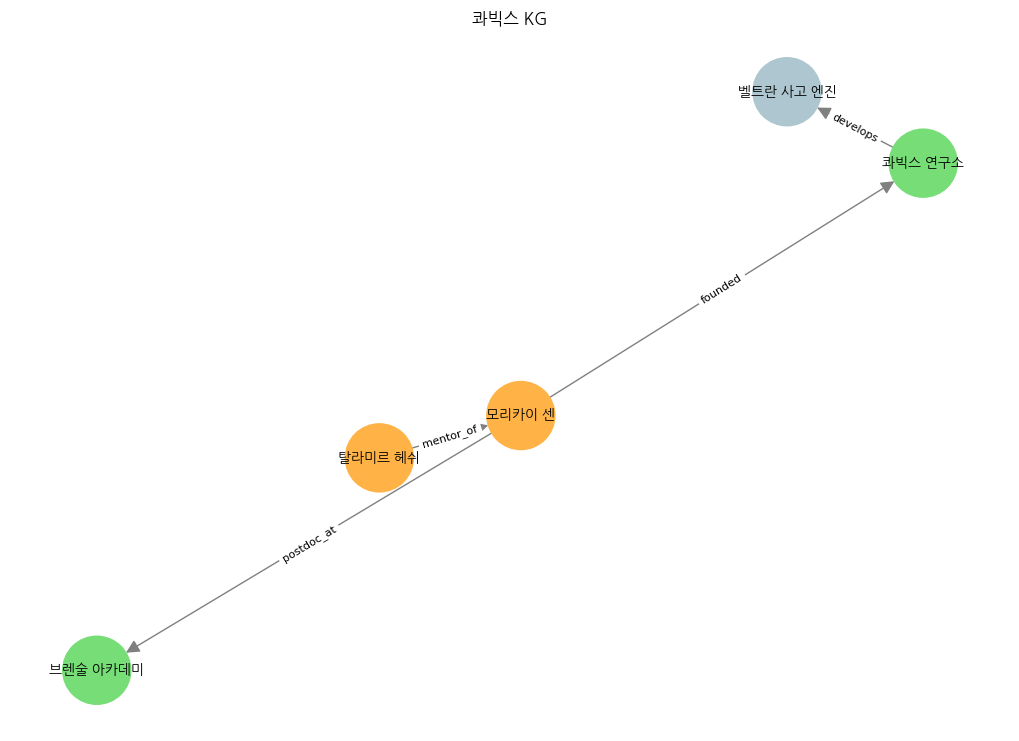

In [53]:
visualize_kg(G_demo, '콰빅스 KG')

In [54]:
# G.successors
# G.predecessors
# G.neighbors

In [55]:
list(G_demo.successors('모리카이 센'))

['콰빅스 연구소', '브렌술 아카데미']

In [56]:
list(G_demo.predecessors('모리카이 센'))

['탈라미르 헤쉬']

In [57]:
G_demo['모리카이 센']['콰빅스 연구소']

{'relation': 'founded', 'year': 1987}

In [58]:
def neighbors_with_labels(G, node):
    out = []
    for v in G.successors(node):
        out.append({'direction' : 'out', 'relation' : G[node][v].get('relation', ''), 'neighbor' : v})
    for u in G.predecessors(node):
        out.append({'direction' : 'in', 'relation' : G[u][node].get('relation', ''), 'neighbor' : u})
    return out

In [59]:
neighbors_with_labels(G_demo, '모리카이 센')

[{'direction': 'out', 'relation': 'founded', 'neighbor': '콰빅스 연구소'},
 {'direction': 'out', 'relation': 'postdoc_at', 'neighbor': '브렌술 아카데미'},
 {'direction': 'in', 'relation': 'mentor_of', 'neighbor': '탈라미르 헤쉬'}]

In [60]:
src, tgt = '탈라미르 헤쉬', '벨트란 사고 엔진'
path = nx.shortest_path(G_demo, src, tgt)

In [61]:
path

['탈라미르 헤쉬', '모리카이 센', '콰빅스 연구소', '벨트란 사고 엔진']

In [62]:
list(nx.all_simple_paths(G_demo, src, tgt, cutoff=3))

[['탈라미르 헤쉬', '모리카이 센', '콰빅스 연구소', '벨트란 사고 엔진']]

In [63]:
def multi_hop_paths(G, src, tgt, max_hops=3):
    results = []
    for path in nx.all_simple_paths(G, src, tgt, cutoff= max_hops):
        rels = [G[path[i]][path[i+1]].get('relation', '') for i in range(len(path)-1)]
        results.append({'path' : path, 'relations' : rels})
        
    return results

In [64]:
for r in multi_hop_paths(G_demo, '탈라미르 헤쉬', '벨트란 사고 엔진', max_hops = 4):
    chain = []
    for i, n in enumerate(r['path']):
        chain.append(n)
    

In [65]:
chain

['탈라미르 헤쉬', '모리카이 센', '콰빅스 연구소', '벨트란 사고 엔진']

In [66]:
nx.pagerank(G_demo)

{'모리카이 센': 0.20691607872108045,
 '콰빅스 연구소': 0.1997859509819727,
 '브렌술 아카데미': 0.1997859509819727,
 '탈라미르 헤쉬': 0.11184682438205981,
 '벨트란 사고 엔진': 0.28166519493291453}

In [67]:
prompt_skel = """You are an information extraction system.
From the text, extract entities and relations as JSON.

IMPORTANT:
- Always extract titles in quotation marks (papers, books, protocols, projects, products)
  as Concept/Publication entities — these are easy to miss.
- When "Person X wrote/authored Title Y" appears, emit an explicit
  (X) --[wrote]--> (Y) relation.

Schema:
{
  "entities": [{"name": "...", "type": "Person|Organisation|Product|Concept|Publication"}],
  "relations": [{"source": "...", "target": "...", "label": "..."}]
}

Output ONLY valid JSON. No other text.

Text:
\"\"\"모리카이 센은 1987년에 콰빅스 연구소를 설립했다.\"\"\""""

In [68]:
print(prompt_skel)

You are an information extraction system.
From the text, extract entities and relations as JSON.

IMPORTANT:
- Always extract titles in quotation marks (papers, books, protocols, projects, products)
  as Concept/Publication entities — these are easy to miss.
- When "Person X wrote/authored Title Y" appears, emit an explicit
  (X) --[wrote]--> (Y) relation.

Schema:
{
  "entities": [{"name": "...", "type": "Person|Organisation|Product|Concept|Publication"}],
  "relations": [{"source": "...", "target": "...", "label": "..."}]
}

Output ONLY valid JSON. No other text.

Text:
"""모리카이 센은 1987년에 콰빅스 연구소를 설립했다."""


In [69]:
import json
def strip_code_fence(text):
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$","", text)
    return text

def extract_graph(text):
    sys = SystemMessage(content = (
    "You are an information extraction system."
    "From the text, extract entities and relations as JSON."

    "IMPORTANT:"
    "- Always extract titles in quotation marks (papers, books, protocols, projects, products)"
    "  as Concept/Publication entities — these are easy to miss."
    "- When 'Person X wrote/authored Title Y' appears, emit an explicit"
    "  (X) --[wrote]--> (Y) relation."    
    ))
    user = HumanMessage(content= (
    'Schema:\n'
    '{"entities": [{"name": "...", "type": "Person|Organisation|Product|Concept|Publication"}],\n'
    '"relations": [{"source": "...", "target": "...", "label": "..."}]}\n\n'
    f'Text:\n\"\"\"{text}\"\"\"'
    ))
    raw = llm.invoke([sys, user]).content
    try:
        return json.loads(strip_code_fence(raw))
    except json.JSONDecodeError:
        return {'entities' : [], 'relations' : []}

In [70]:
para1 = text.split("제목:")[1]
result = extract_graph("제목:" + para1)

In [71]:
result

{'entities': [{'name': '모리카이 센', 'type': 'Person'},
  {'name': '콰빅스 연구소', 'type': 'Organisation'},
  {'name': '브렌술 아카데미', 'type': 'Organisation'},
  {'name': '탈라미르 헤쉬', 'type': 'Person'},
  {'name': '벨트란 사고 엔진', 'type': 'Product'},
  {'name': '눌마리 연구 위원회', 'type': 'Organisation'}],
 'relations': [{'source': '모리카이 센', 'target': '콰빅스 연구소', 'label': 'founded'},
  {'source': '모리카이 센', 'target': '탈라미르 헤쉬', 'label': 'mentor'},
  {'source': '탈라미르 헤쉬', 'target': '논문', 'label': 'supervised'},
  {'source': '모리카이 센', 'target': '논문', 'label': 'wrote'},
  {'source': '콰빅스 연구소', 'target': '벨트란 사고 엔진', 'label': 'project'},
  {'source': '콰빅스 연구소', 'target': '눌마리 연구 위원회', 'label': 'sponsor'}]}

In [72]:
print(f"entities : {len(result['entities'])}, relations : {len(result['relations'])}")

entities : 6, relations : 6


In [73]:
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "entities": [
    {
      "name": "모리카이 센",
      "type": "Person"
    },
    {
      "name": "콰빅스 연구소",
      "type": "Organisation"
    },
    {
      "name": "브렌술 아카데미",
      "type": "Organisation"
    },
    {
      "name": "탈라미르 헤쉬",
      "type": "Person"
    },
    {
      "name": "벨트란 사고 엔진",
      "type": "Product"
    },
    {
      "name": "눌마리 연구 위원회",
      "type": "Organisation"
    }
  ],
  "relations": [
    {
      "source": "모리카이 센",
      "target": "콰빅스 연구소",
      "label": "founded"
    },
    {
      "source": "모리카이 센",
      "target": "탈라미르 헤쉬",
      "label": "mentor"
    },
    {
      "source": "탈라미르 헤쉬",
      "target": "논문",
      "label": "supervised"
    },
    {
      "source": "모리카이 센",
      "target": "논문",
      "label": "wrote"
    },
    {
      "source": "콰빅스 연구소",
      "target": "벨트란 사고 엔진",
      "label": "project"
    },
    {
      "source": "콰빅스 연구소",
      "target": "눌마리 연구 위원회",
      "label": "sponsor"
    }
  ]
}


In [74]:
# llm.with_structured_output

In [75]:
from pydantic import BaseModel, Field
from typing import Literal

In [76]:
class Entity(BaseModel):
    name : str
    type : Literal["Person", "Organisation", "Product", "Concept", "Publication"]

class Relation(BaseModel):
    source : str
    target : str
    label : str

class ExtractedKG(BaseModel):
    entities : list[Entity]
    relations : list[Relation]

In [77]:
structured_llm = llm.with_structured_output(ExtractedKG)

In [78]:
para1

' 콰빅스 연구소\n모리카이 센은 1987 년 초여름에 눌마리 섬에서 콰빅스 연구소를 설립했다. 센은 콰빅스를 세우기 전 11 년 동안 브렌술 아카데미의 박사후 연구원으로 지냈으며, 그 시절 그녀의 지도 멘토는 탈라미르 헤쉬였다. 헤쉬는 센이 발표한 초기 논문 두 편의 지도 교수였고, 공식 기록에도 센의 박사 학위 지도 교수로 등재되어 있다. 콰빅스의 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며, 현재 눌마리 연구 위원회가 주요 후원 기관 중 하나로 올라 있다.\n\n'

In [79]:
demo_kg = structured_llm.invoke(f"다음 텍스트에서 엔티티/관계를 추출하세요:\n{para1}")

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedKG(entities=[Ent...주요 후원 기관')]), input_type=ExtractedKG])
  return self.__pydantic_serializer__.to_python(


In [80]:
demo_kg

ExtractedKG(entities=[Entity(name='콰빅스 연구소', type='Organisation'), Entity(name='모리카이 센', type='Person'), Entity(name='브렌술 아카데미', type='Organisation'), Entity(name='탈라미르 헤쉬', type='Person'), Entity(name='벨트란 사고 엔진', type='Product'), Entity(name='눌마리 연구 위원회', type='Organisation')], relations=[Relation(source='모리카이 센', target='콰빅스 연구소', label='설립'), Relation(source='모리카이 센', target='브렌술 아카데미', label='박사후 연구원'), Relation(source='탈라미르 헤쉬', target='모리카이 센', label='지도 멘토'), Relation(source='탈라미르 헤쉬', target='모리카이 센', label='지도 교수'), Relation(source='콰빅스 연구소', target='벨트란 사고 엔진', label='대표 프로젝트'), Relation(source='눌마리 연구 위원회', target='콰빅스 연구소', label='주요 후원 기관')])

In [81]:
demo_kg.entities

[Entity(name='콰빅스 연구소', type='Organisation'),
 Entity(name='모리카이 센', type='Person'),
 Entity(name='브렌술 아카데미', type='Organisation'),
 Entity(name='탈라미르 헤쉬', type='Person'),
 Entity(name='벨트란 사고 엔진', type='Product'),
 Entity(name='눌마리 연구 위원회', type='Organisation')]

In [82]:
demo_kg.relations

[Relation(source='모리카이 센', target='콰빅스 연구소', label='설립'),
 Relation(source='모리카이 센', target='브렌술 아카데미', label='박사후 연구원'),
 Relation(source='탈라미르 헤쉬', target='모리카이 센', label='지도 멘토'),
 Relation(source='탈라미르 헤쉬', target='모리카이 센', label='지도 교수'),
 Relation(source='콰빅스 연구소', target='벨트란 사고 엔진', label='대표 프로젝트'),
 Relation(source='눌마리 연구 위원회', target='콰빅스 연구소', label='주요 후원 기관')]

In [83]:
def extracted_graph_typed(text) -> ExtractedKG:
    structured_llm = llm.with_structured_output(ExtractedKG)
    prompt = ("다음 텍스트에서 엔티티(Person/Organisation/Product/Concept/Publication)와 관계를 추출하세요."
              f"텍스트 : {text}")
    return structured_llm.invoke(prompt)

In [84]:
mini_dict = {
    "entities" : [{'name' : 'A', 'type' : 'Person'}, {'name' : 'B', 'type' : 'Organisation'}],
    'relations' : [{'source' : 'A', 'target' : 'B', 'label' : 'founded'}]
}

In [85]:
G_mini = nx.DiGraph()
for e in mini_dict['entities']:
    G_mini.add_node(e['name'], type=e['type'])
for r in mini_dict['relations']:
    G_mini.add_edge(r['source'], r['target'], relation=r['label'])

In [86]:
dict(G_mini.nodes(data=True))

{'A': {'type': 'Person'}, 'B': {'type': 'Organisation'}}

In [87]:
def json_to_graph(data) -> nx.DiGraph:
    G = nx.DiGraph()
    for e in data.get('entities', []):
        G.add_node(e['name'], type=e.get('type', 'unknown'))
    for r in data.get('relations', []):
        if r['source'] not in G:
            G.add_node(r['source'], type='unknown')
        if r['target'] not in G:
            G.add_node(r['target'], type='unknown')
        G.add_edge(r['source'], r['target'], relation=r.get('label', ''))
    return G

In [88]:
G_extracted = json_to_graph(result)

In [89]:
G_extracted.number_of_nodes(), G_extracted.number_of_edges()

(7, 6)

In [90]:
result

{'entities': [{'name': '모리카이 센', 'type': 'Person'},
  {'name': '콰빅스 연구소', 'type': 'Organisation'},
  {'name': '브렌술 아카데미', 'type': 'Organisation'},
  {'name': '탈라미르 헤쉬', 'type': 'Person'},
  {'name': '벨트란 사고 엔진', 'type': 'Product'},
  {'name': '눌마리 연구 위원회', 'type': 'Organisation'}],
 'relations': [{'source': '모리카이 센', 'target': '콰빅스 연구소', 'label': 'founded'},
  {'source': '모리카이 센', 'target': '탈라미르 헤쉬', 'label': 'mentor'},
  {'source': '탈라미르 헤쉬', 'target': '논문', 'label': 'supervised'},
  {'source': '모리카이 센', 'target': '논문', 'label': 'wrote'},
  {'source': '콰빅스 연구소', 'target': '벨트란 사고 엔진', 'label': 'project'},
  {'source': '콰빅스 연구소', 'target': '눌마리 연구 위원회', 'label': 'sponsor'}]}

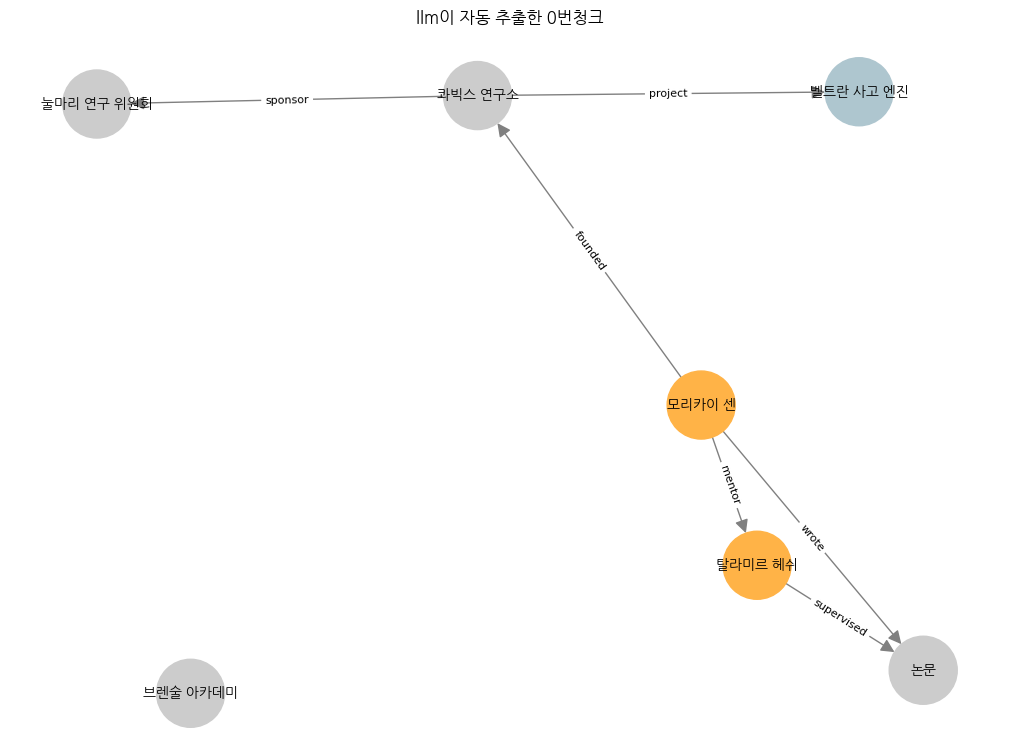

In [91]:
visualize_kg(G_extracted, 'llm이 자동 추출한 0번청크')

In [92]:
# '모리카이 센' : person
# '센' : person
# '모리카이' : person
# ...



In [93]:
nodes = ['모리카이 센', '센', '콰빅스 연구소', '콰빅스', '벨트란 사고 엔진']
def find_aliases(nodes):
    aliases = {}
    for short in nodes: # 센
        for long in nodes: # 모리카이 센
            if short != long and len(short) < len(long) and short in long:
                aliases[short] = long  # aliases['센'] = '모리카이 센'
                break
    return aliases

In [94]:
find_aliases(nodes)

{'센': '모리카이 센', '콰빅스': '콰빅스 연구소'}

In [95]:
def resolve_entities(G: nx.DiGraph) -> nx.DiGraph:
    nodes = list(G.nodes)
    
    aliases = {}
    for short in nodes: # 센
        for long in nodes: # 모리카이 센
            if short != long and len(short) < len(long) and short in long:
                aliases[short] = long  # aliases['센'] = '모리카이 센'
                break
    
    def resolve(n):
        
        seen = set()
        
        while n in aliases and n not in seen:
            seen.add(n)
            n = aliases[n]
        
        return n
    
    G2 = nx.DiGraph()
    for n in nodes:
        c = resolve(n)
        if c not in G2:
            G2.add_node(c, **G.nodes[n])
    
    for u, v, d in G.edges(data=True):
        cu, cv = resolve(u), resolve(v)
        
        if cu == cv:
            continue
        if G2.has_edge(cu, cv):
            continue
        G2.add_edge(cu, cv, **d)
    
    return G2

In [96]:
G_demo.number_of_nodes(), G_demo.number_of_edges()

(5, 4)

In [97]:
G_demo.nodes()

NodeView(('모리카이 센', '콰빅스 연구소', '브렌술 아카데미', '탈라미르 헤쉬', '벨트란 사고 엔진'))

In [98]:
G_alias = G_demo.copy()
G_alias.add_node('센', type='Person')
G_alias.add_edge('센', '벨트란 사고 엔진', relation='proposed')
G_alias.number_of_nodes(), G_alias.number_of_edges()

(6, 5)

In [99]:
G_alias.nodes()

NodeView(('모리카이 센', '콰빅스 연구소', '브렌술 아카데미', '탈라미르 헤쉬', '벨트란 사고 엔진', '센'))

In [100]:
G_resolved = resolve_entities(G_alias)

In [101]:
G_resolved.number_of_nodes(), G_resolved.number_of_edges()

(5, 5)

In [102]:
G_resolved.nodes()

NodeView(('모리카이 센', '콰빅스 연구소', '브렌술 아카데미', '탈라미르 헤쉬', '벨트란 사고 엔진'))

In [103]:
for u, v, d in G_resolved.edges(data=True):
    print(f" ({u}) ---[{d.get('relation', '')}]-----> ({v})")

 (모리카이 센) ---[founded]-----> (콰빅스 연구소)
 (모리카이 센) ---[postdoc_at]-----> (브렌술 아카데미)
 (모리카이 센) ---[proposed]-----> (벨트란 사고 엔진)
 (콰빅스 연구소) ---[develops]-----> (벨트란 사고 엔진)
 (탈라미르 헤쉬) ---[mentor_of]-----> (모리카이 센)


In [104]:
# 센의 멘토가 쓴 논문 제목은 무엇인가요?

In [105]:
G_full = G_demo.copy()

G_full.add_node("눌마리 연구 위원회", type="Organisation")
G_full.add_edge("눌마리 연구 위원회", "콰빅스 연구소", relation="funds")

G_full.add_node("공명 프레임에 관하여", type="Publication")
G_full.add_edge("탈라미르 헤쉬", "공명 프레임에 관하여", relation="wrote")

G_full.add_node("타즈렌 연구소", type="Organisation")
G_full.add_node("에빈 브로스", type="Person")
G_full.add_node("할렌 프로토콜", type="Publication")
G_full.add_edge("에빈 브로스", "타즈렌 연구소", relation="works_at")
G_full.add_edge("에빈 브로스", "할렌 프로토콜", relation="wrote")
G_full.add_edge("눌마리 연구 위원회", "할렌 프로토콜", relation="adopts")

In [106]:
def answer_via_kg(G, src, tgt_keyword, max_hops=4):
    if src not in G:
        return f"src '{src}' not in graph"
    
    candidates = [n for n in G.nodes if tgt_keyword in n]
    if not candidates:
        return f"keyword '{tgt_keyword}' 포함한 노드 없음"
    
    Gu = G.to_undirected()
    best = None
    for tgt in candidates:
        try:
            paths = list(nx.all_simple_paths(Gu, src, tgt, cutoff=max_hops))
            if paths:
                shortest = min(paths, key=len)
                if best is None or len(shortest) < len(best):
                    best = shortest
        except nx.NodeNotFound:
            continue
    
    if best is None:
        return '경로 없음'
    
    return best[-1]

In [107]:
answer_via_kg(G_full, '모리카이 센', '공명', max_hops=4)

'공명 프레임에 관하여'

In [108]:
answer_via_kg(G_full, '탈라미르 헤쉬', '프레임', max_hops=4)

'공명 프레임에 관하여'

In [109]:
# 에빈 브로스와 콰빅스 연구소는 어떤 관계?

In [110]:
def find_relation(G, e1, e2, max_hops=4):
    Gu = G.to_undirected()
    if e1 not in Gu or e2 not in Gu:
        return None
    try:
        return nx.shortest_path(Gu, e1, e2)
    except nx.NetworkXNoPath:
        return None

In [111]:
path = find_relation(G_full, '에빈 브로스', '콰빅스 연구소')

In [112]:
path

['에빈 브로스', '할렌 프로토콜', '눌마리 연구 위원회', '콰빅스 연구소']

In [113]:
print(f"({len(path)-1} hop): {' -> '.join(path)}")

(3 hop): 에빈 브로스 -> 할렌 프로토콜 -> 눌마리 연구 위원회 -> 콰빅스 연구소


In [114]:
def explain_relation(G, e1, e2, max_hops=4) -> str:
    Gu = G.to_undirected()
    if e1 not in Gu or e2 not in Gu:
        missing = e1 if e1 not in Gu else e2
        return f"'{missing}'을 그래프에서 못찾음"
    try:
        path = nx.shortest_path(Gu, e1, e2)
    except nx.NetworkXNoPath:
        return f"'{e1}' 과 '{e2}' 사이에 경로가 없음"
    
    if len(path) > max_hops + 1:
        return f"경로가 너무 김 ({len(path)-1}hops)"
    
    parts = [path[0]]
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        rel = G[u][v].get('relation') if G.has_edge(u, v) else G[v][u].get('relation', '?')
        arrow = "->" if G.has_edge(u, v) else  "<-"
        parts.append(f"{arrow}[{rel}]{arrow}")  # ->[works_at]->
        parts.append(v)
    
    return " ".join(parts)

In [115]:
explain_relation(G_full, '에빈 브로스', '콰빅스 연구소')

'에빈 브로스 ->[wrote]-> 할렌 프로토콜 <-[adopts]<- 눌마리 연구 위원회 ->[funds]-> 콰빅스 연구소'

In [116]:
explain_relation(G_full, '모리카이 센', '할렌 프로토콜')

'모리카이 센 ->[founded]-> 콰빅스 연구소 <-[funds]<- 눌마리 연구 위원회 ->[adopts]-> 할렌 프로토콜'

In [117]:
def neighbors_to_text(G, node):
    lines = []
    for nb in G.successors(node):
        lines.append(f"({node})--[{G[node][nb].get('relation', '')}]--> ({nb})")
    for pr in G.predecessors(node):
        lines.append(f"({pr})--[{G[pr][node].get('relation', '')}]--> ({node})")
    return '\n'.join(lines)

In [118]:
print(neighbors_to_text(G_full, '모리카이 센'))

(모리카이 센)--[founded]--> (콰빅스 연구소)
(모리카이 센)--[postdoc_at]--> (브렌술 아카데미)
(탈라미르 헤쉬)--[mentor_of]--> (모리카이 센)


In [122]:
def kg_to_text(G, focus_nodes, question) : 
    lines = []
    seen = set()
    for node in focus_nodes:
        if node not in G:
            continue
        for nb in G.successors(node):
            if (node, nb) in seen:
                continue
            seen.add((node, nb))
            lines.append(f"({node}) --[{G[node][nb].get('relation', '')}]--> ({nb})")
        for pr in G.predecessors(node):
            if (pr, node) in seen:
                continue
            seen.add((pr, node))
            lines.append(f"({pr}) --[{G[pr][node].get('relation', '')}]--> ({node})")
    
    kg_text = '\n'.join(lines) if lines else "이웃 정보 없음"
    
    sys_msg = SystemMessage(content = (
            "아래 지식 그래프 사실들만 보고 한국어로 간결히 답하세요"
            "근거가 없으면 '확인 불가' 라고 답하세요"
    ))
    
    user_msg = HumanMessage(content= f"질문: {question}\n\nKG 사실: {kg_text}")
    return llm.invoke([sys_msg, user_msg]).content
    
        

In [123]:
kg_to_text(G_full, ['모리카이 센', '탈라미르 헤쉬'], question='모리카이 센과 헤쉬는 어떤 관계인가요?')

'모리카이 센은 탈라미르 헤쉬의 멘토입니다.'

In [124]:
!pip install graspologic


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
